# 🏦 Loan Prediction — Phase 1: Data Preprocessing
**Pipeline:** Exploration → Missing Values → Feature Engineering → Encoding → Scaling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import joblib, warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")


## 1. Data Exploration

In [2]:
df = pd.read_csv('Datasets/Train data.csv')
df.drop('Loan_ID', axis=1, inplace=True)

print(f"Shape: {df.shape}  →  614 rows, 13 attributes (after dropping Loan_ID)")
df.head()


Shape: (614, 12)  →  614 rows, 13 attributes (after dropping Loan_ID)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.7 KB


In [4]:
# Unique values per column
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()}")
    else:
        print(f"{col}: {df[col].nunique()} unique values")


Gender: 2 unique values
Married: 2 unique values
Dependents: 4 unique values
Education: 2 unique values
Self_Employed: 2 unique values
ApplicantIncome: 505 unique values
CoapplicantIncome: 287 unique values
LoanAmount: 203 unique values
Loan_Amount_Term: 10 unique values
Credit_History: 2 unique values
Property_Area: 3 unique values
Loan_Status: 2 unique values


In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


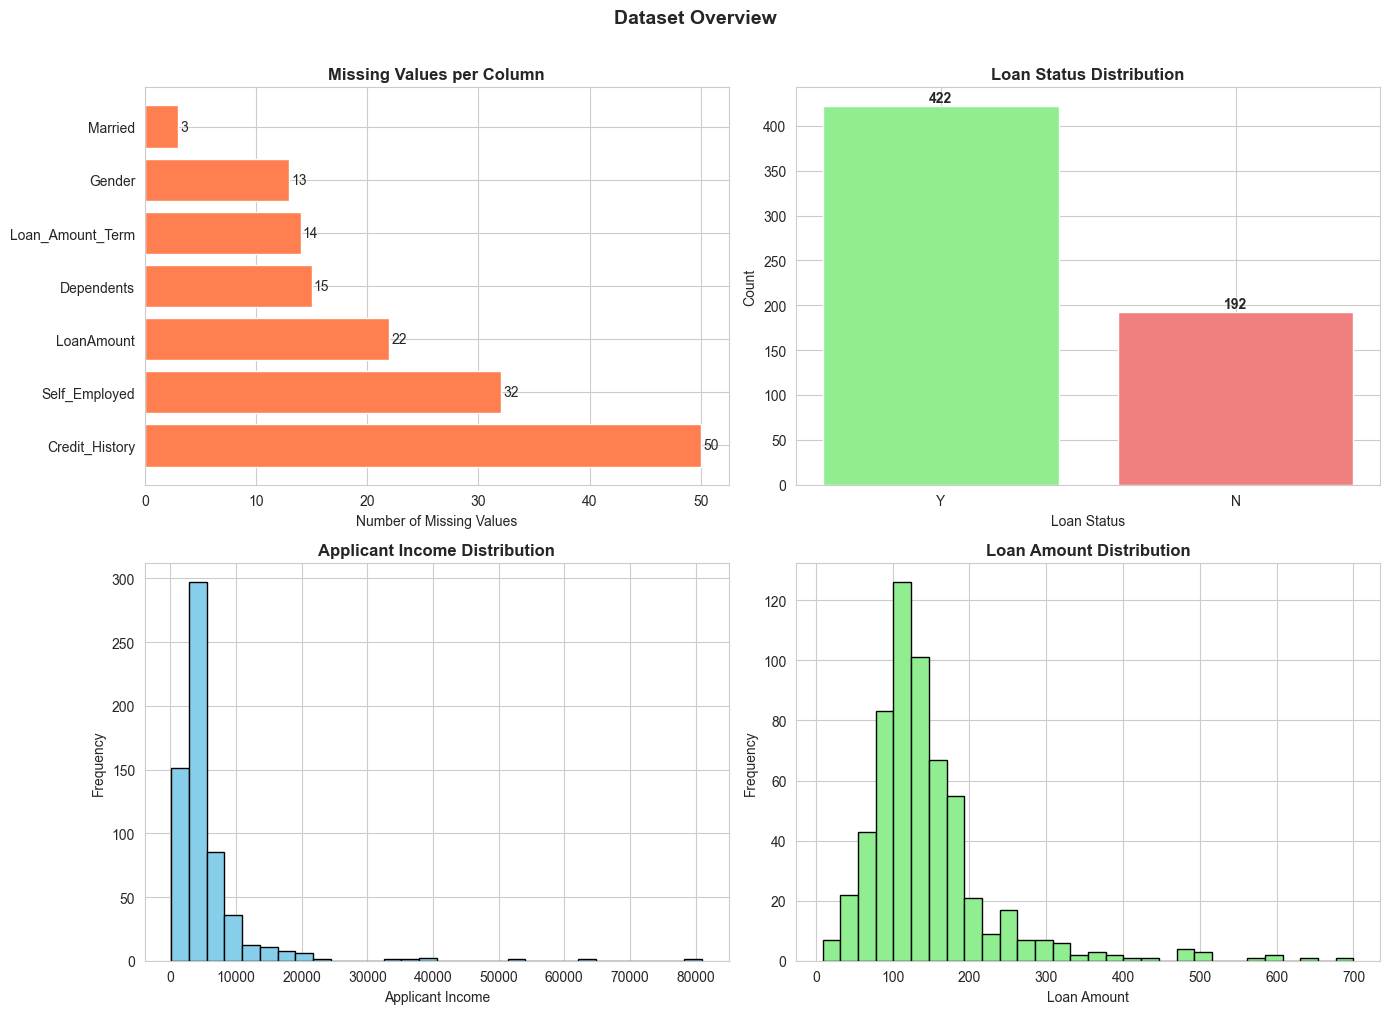

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1a. Missing values bar chart
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
axes[0, 0].barh(missing.index, missing.values, color='coral')
axes[0, 0].set_xlabel('Number of Missing Values')
axes[0, 0].set_title('Missing Values per Column', fontweight='bold')
for i, v in enumerate(missing.values):
    axes[0, 0].text(v + 0.2, i, str(v), va='center')

# 1b. Target variable distribution
counts = df['Loan_Status'].value_counts()
axes[0, 1].bar(counts.index, counts.values, color=['lightgreen', 'lightcoral'])
axes[0, 1].set_xlabel('Loan Status'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Loan Status Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0, 1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 1c. Applicant Income distribution
df['ApplicantIncome'].hist(bins=30, ax=axes[1, 0], color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Applicant Income'); axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Applicant Income Distribution', fontweight='bold')

# 1d. Loan Amount distribution
df['LoanAmount'].hist(bins=30, ax=axes[1, 1], color='lightgreen', edgecolor='black')
axes[1, 1].set_xlabel('Loan Amount'); axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Loan Amount Distribution', fontweight='bold')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()


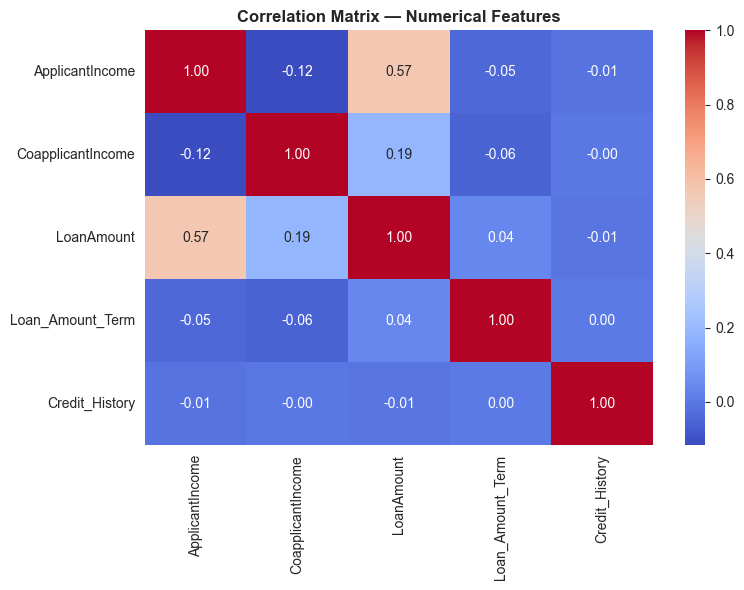

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150)
plt.show()


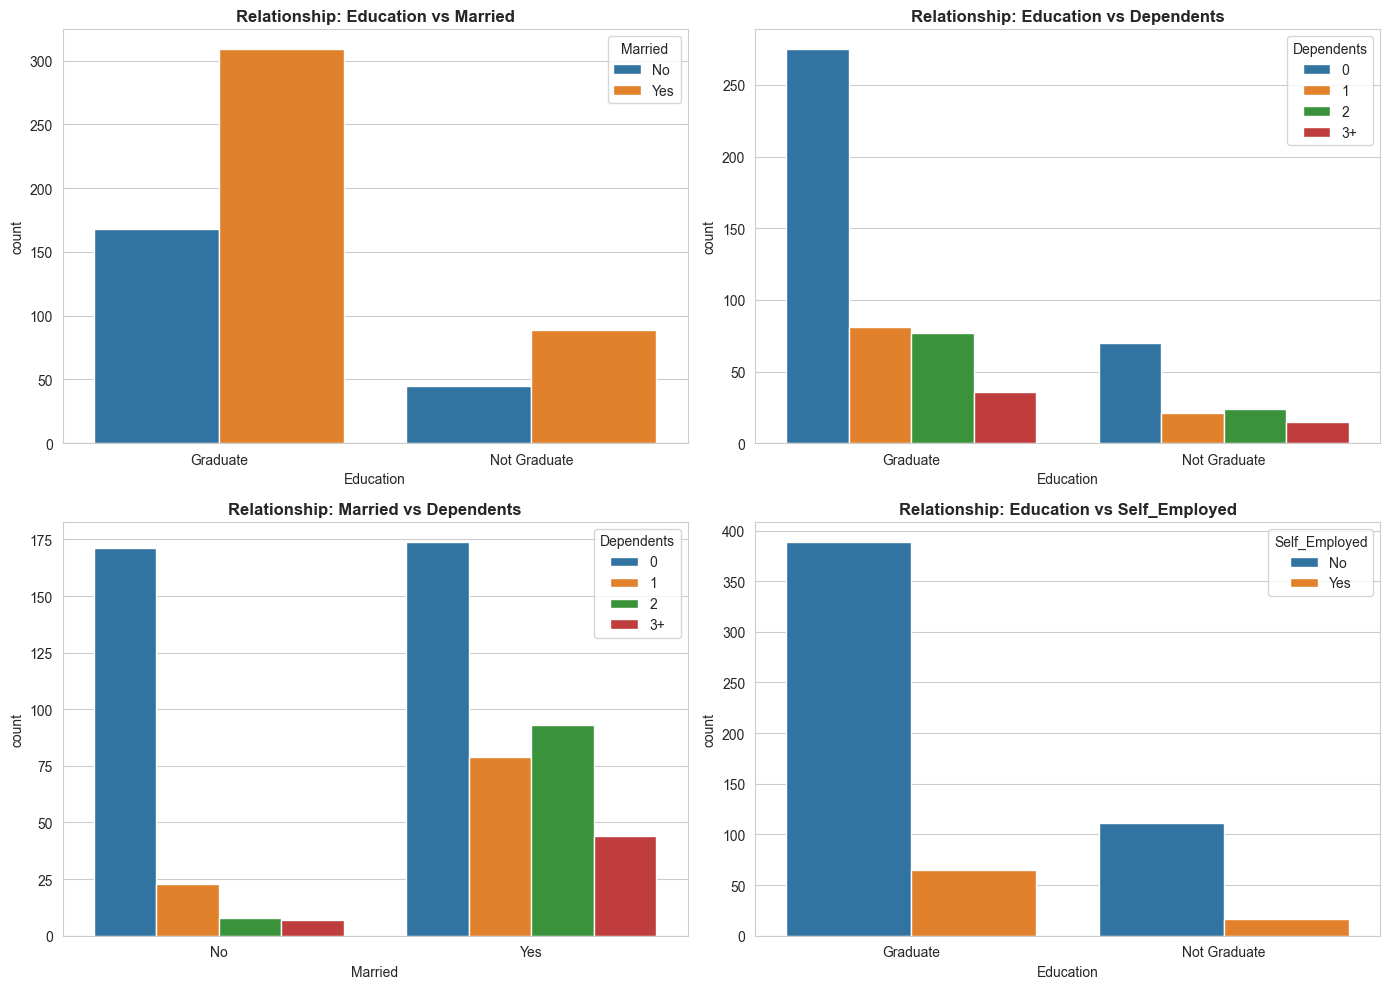

In [8]:
pairs = [
    ('Education',  'Married',       'Relationship: Education vs Married'),
    ('Education',  'Dependents',    'Relationship: Education vs Dependents'),
    ('Married',    'Dependents',    'Relationship: Married vs Dependents'),
    ('Education',  'Self_Employed', 'Relationship: Education vs Self_Employed'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (x, hue, title) in zip(axes.flat, pairs):
    sns.countplot(x=x, hue=hue, data=df, ax=ax)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categorical_relationships.png', dpi=150)
plt.show()


## 2. Handling Missing Values

| Column | Strategy |
|---|---|
| Gender | Mode imputation |
| Married | Rule-based: Graduate → Yes, Non-Graduate → No |
| Dependents | Group mode by Married status |
| Self_Employed | Mode imputation |
| LoanAmount | RandomForestRegressor prediction |
| Loan_Amount_Term | Mode imputation |
| Credit_History | Mode imputation |


In [9]:
# Gender — mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

# Married — rule-based (Graduates more likely married)
df.loc[df['Married'].isnull() & (df['Education'] == 'Graduate'),     'Married'] = 'Yes'
df.loc[df['Married'].isnull() & (df['Education'] == 'Not Graduate'), 'Married'] = 'No'

# Dependents — group mode by Married status
df['Dependents'] = df.groupby('Married')['Dependents'].transform(
    lambda x: x.fillna(x.mode()[0]))

# Self_Employed, Loan_Amount_Term, Credit_History — mode
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("After simple imputation — remaining nulls:")
print(df.isnull().sum())


After simple imputation — remaining nulls:
Gender               13
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [10]:
# LoanAmount — RandomForestRegressor on complete rows
rf_features = ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
               'Credit_History', 'Gender', 'Married', 'Dependents',
               'Education', 'Self_Employed', 'Property_Area']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

complete = df[df['LoanAmount'].notnull()]
missing  = df[df['LoanAmount'].isnull()]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

def encode_for_rf(data, ohe, fit=False):
    num = data[['ApplicantIncome','CoapplicantIncome','Loan_Amount_Term','Credit_History']].reset_index(drop=True)
    enc = ohe.fit_transform(data[cat_cols]) if fit else ohe.transform(data[cat_cols])
    cat = pd.DataFrame(enc, columns=ohe.get_feature_names_out(cat_cols))
    return pd.concat([num, cat], axis=1)

X_tr_rf = encode_for_rf(complete, ohe, fit=True)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_tr_rf, complete['LoanAmount'].values)

df.loc[df['LoanAmount'].isnull(), 'LoanAmount'] = rf.predict(
    encode_for_rf(missing, ohe))

print("After RF imputation — remaining nulls:")
print(df.isnull().sum())


After RF imputation — remaining nulls:
Gender               13
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## 3. Feature Engineering
- `TotalIncome` = ApplicantIncome + CoapplicantIncome
- Log-transform LoanAmount & TotalIncome
- Gentle capping at 99.5th percentile

In [11]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']


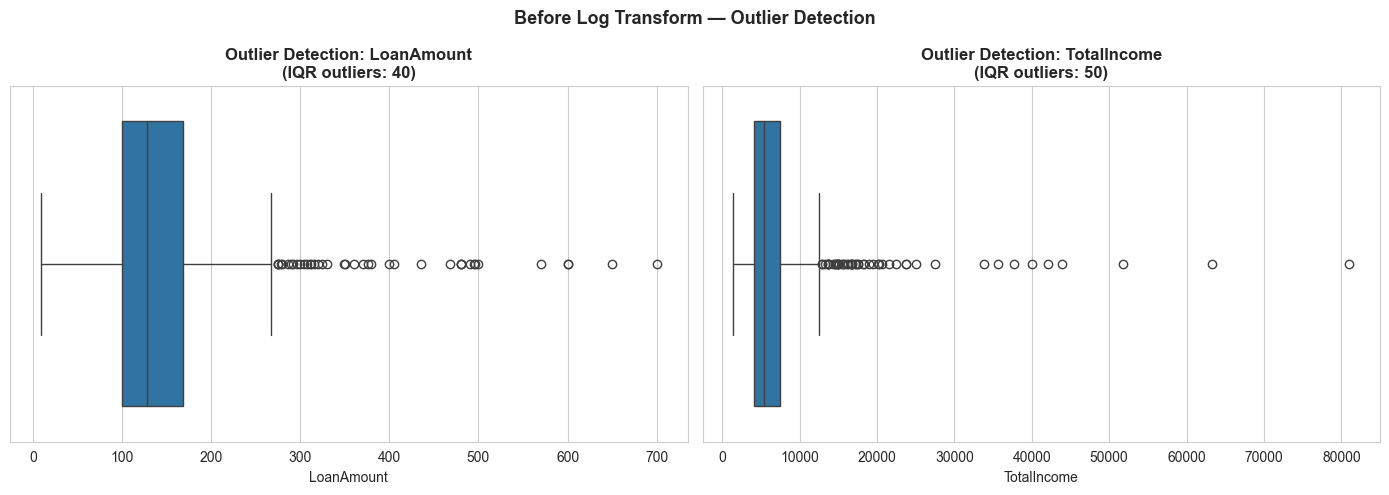

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['LoanAmount', 'TotalIncome']):
    sns.boxplot(x=df[col], ax=ax)
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'Outlier Detection: {col}\n(IQR outliers: {n_out})', fontweight='bold')
    ax.set_xlabel(col)
plt.suptitle('Before Log Transform — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_boxplots_before_log.png', dpi=150)
plt.show()


In [13]:
# Log transform
df['LoanAmount_log']  = np.log(df['LoanAmount'] + 1)
df['TotalIncome_log'] = np.log(df['TotalIncome'] + 1)


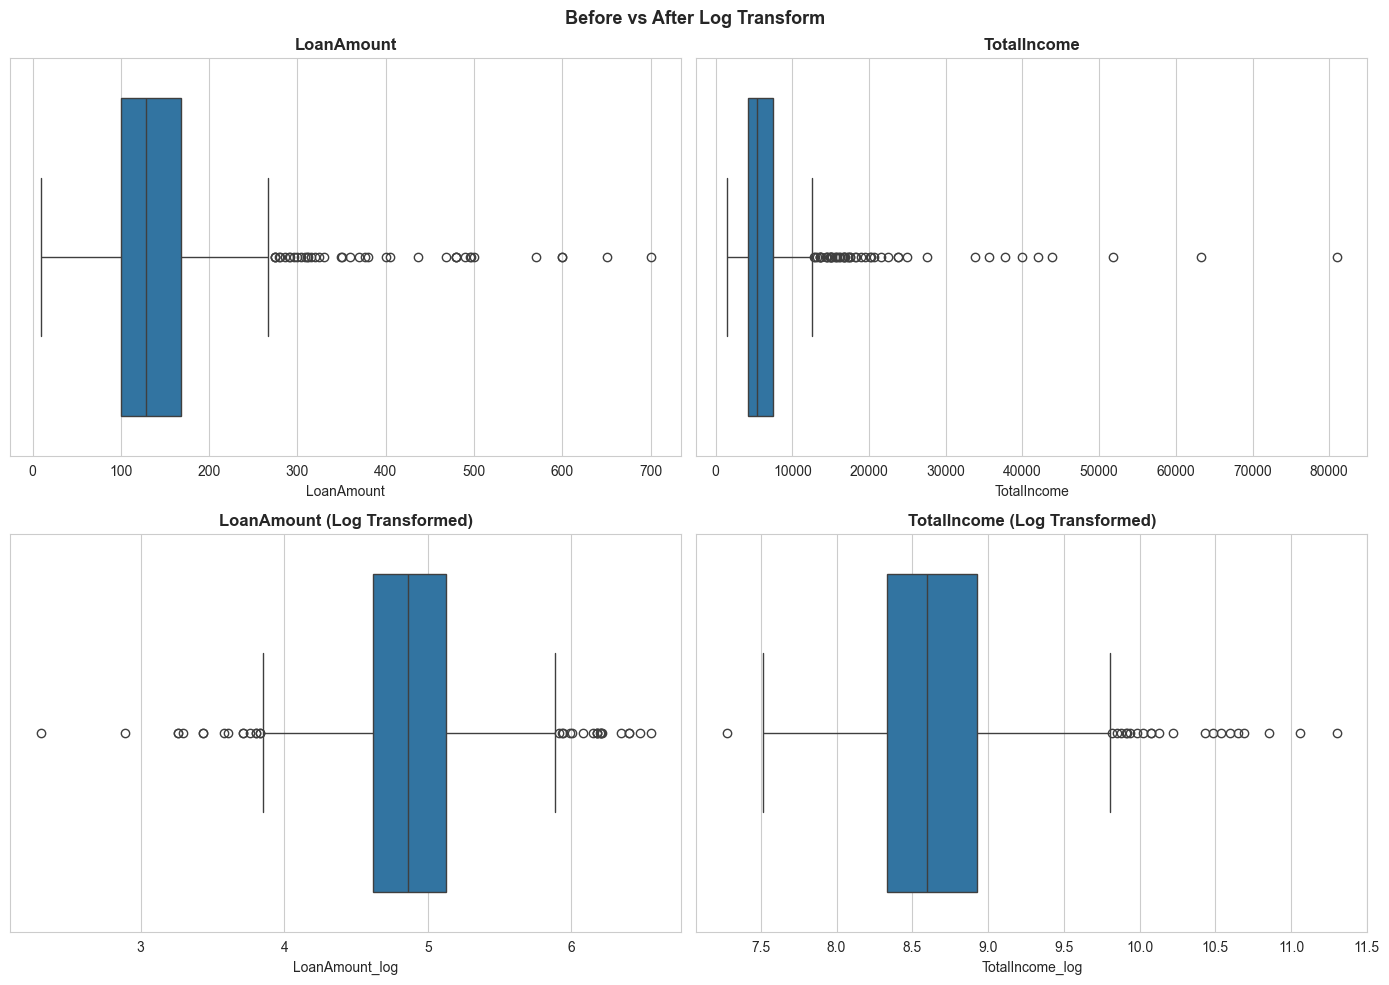

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat,
                   ['LoanAmount', 'TotalIncome', 'LoanAmount_log', 'TotalIncome_log']):
    sns.boxplot(x=df[col], ax=ax)
    label = col.replace('_log', ' (Log Transformed)')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
plt.suptitle('Before vs After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_log_transform_boxplots.png', dpi=150)
plt.show()


In [15]:
# Gentle capping at 99.5th percentile
caps = {}
for col in ['LoanAmount_log', 'TotalIncome_log']:
    cap = df[col].quantile(0.995)
    df[col] = np.clip(df[col], None, cap)
    caps[col] = cap
    print(f"  {col} capped at {cap:.4f}")

joblib.dump(caps, 'log_caps.pkl')


  LoanAmount_log capped at 6.3953
  TotalIncome_log capped at 10.6869


['log_caps.pkl']

In [16]:
# Drop raw columns; keep only log versions
df.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'],
        axis=1, inplace=True)


## 4. Encoding & Scaling

In [17]:
# Ordinal — Label Encoding
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
df['Education']  = df['Education'].map({'Not Graduate': 0, 'Graduate': 1})

# Nominal — One-Hot Encoding
df = pd.get_dummies(df,
                    columns=['Gender', 'Married', 'Self_Employed', 'Property_Area'],
                    drop_first=True)

# Target — Label Encoding
df['Loan_Status'] = LabelEncoder().fit_transform(df['Loan_Status'])

print("Encoded dataframe shape:", df.shape)
df.head()


Encoded dataframe shape: (614, 12)


,Dependents,Education,Loan_Amount_Term,Credit_History,Loan_Status,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,360.0,1.0,1,4.978043,8.674197,True,False,False,False,True
1,1,1,360.0,1.0,0,4.859812,8.714732,True,True,False,False,False
2,0,1,360.0,1.0,1,4.204693,8.006701,True,True,True,False,True
3,0,0,360.0,1.0,1,4.795791,8.505525,True,True,False,False,True
4,0,1,360.0,1.0,1,4.955827,8.699681,True,False,False,False,True


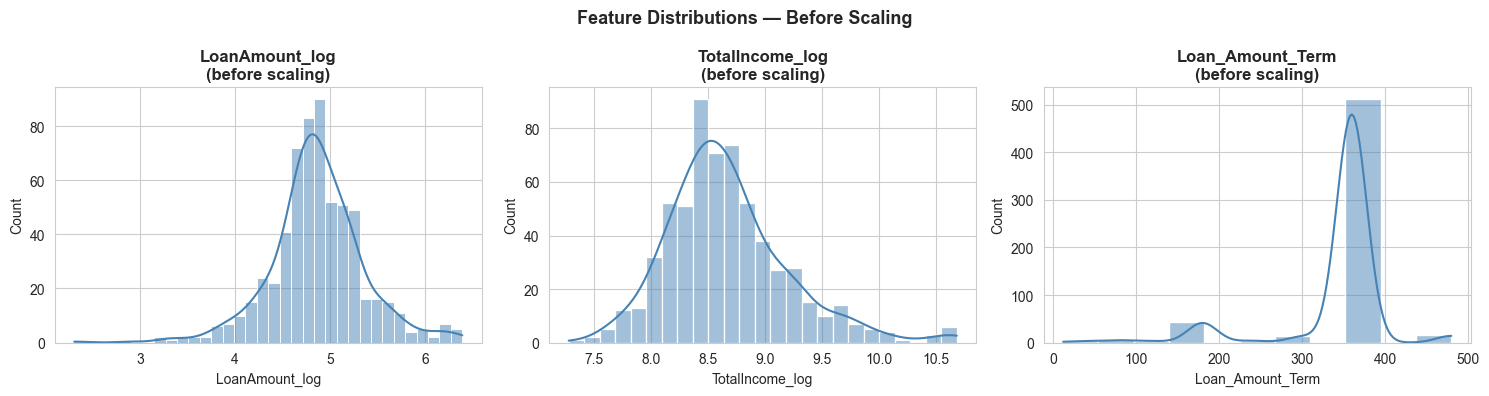

In [18]:
scale_cols = ['LoanAmount_log', 'TotalIncome_log', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, scale_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col}\n(before scaling)', fontweight='bold')
plt.suptitle('Feature Distributions — Before Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_distributions_before_scaling.png', dpi=150)
plt.show()


In [19]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])


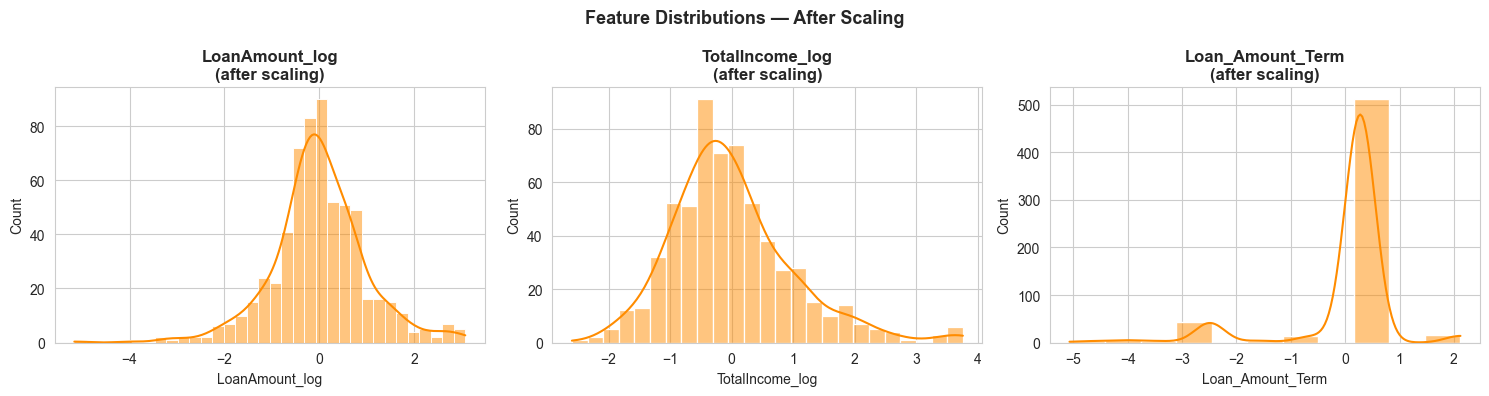

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, scale_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='darkorange')
    ax.set_title(f'{col}\n(after scaling)', fontweight='bold')
plt.suptitle('Feature Distributions — After Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_distributions_after_scaling.png', dpi=150)
plt.show()


In [21]:
# Save artefacts for Phase 2
df.to_csv('preprocessed_data.csv', index=False)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(rf,     'loanamount_regressor.pkl')
joblib.dump(ohe,    'loanamount_ohe.pkl')
joblib.dump(list(df.drop('Loan_Status', axis=1).columns), 'training_columns.pkl')
joblib.dump({'gender_mode': 'Male', 'self_employed_mode': 'No',
             'loan_term_mode': 360.0, 'credit_history_mode': 1.0},
            'simple_imputers.pkl')

print("✅ Phase 1 complete!")
print(f"   Final shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")


✅ Phase 1 complete!
   Final shape: (614, 12)
   Columns: ['Dependents', 'Education', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'LoanAmount_log', 'TotalIncome_log', 'Gender_Male', 'Married_Yes', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
